In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data= pd.read_csv("data/fra_cleaned.csv", sep=";")

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24063 entries, 0 to 24062
Data columns (total 18 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   url                                                                          24063 non-null  object 
 1   Perfume                                                                      24063 non-null  object 
 2   Brand                                                                        24063 non-null  object 
 3   Country                                                                      24063 non-null  object 
 4   Gender                                                                       24063 non-null  object 
 5   Rating Value                                                                 24063 non-null  object 
 6   Rating Count                          

In [5]:
data.describe()

,Rating Count,Year
count,24063.000000,22026.000000
mean,501.396542,2012.455961
std,1429.484690,13.526737
min,26.000000,1781.000000
25%,56.000000,2010.000000
50%,127.000000,2015.000000
75%,360.000000,2019.000000
max,29858.000000,2024.000000


In [6]:
data.sample()

,url,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,"mainaccord5,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,"
2461,https://www.fragrantica.com/perfume/wilgermain...,inconfessable,wilgermain,Spain,unisex,"3,62",26,2020.0,"black pepper, pepper, ginger","nutmeg, coriander, cardamom","cedar, woody notes, patchouli",rodrigo flores-roux,NaN,fresh spicy,warm spicy,woody,aromatic,",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,..."


In [7]:
data.shape

(24063, 18)

In [8]:
data.dtypes

url                                                                             object
Perfume                                                                         object
Brand                                                                           object
Country                                                                         object
Gender                                                                          object
Rating Value                                                                    object
Rating Count                                                                     int64
Year                                                                           float64
Top                                                                             object
Middle                                                                          object
Base                                                                            object
Perfumer1                                  

In [9]:
data.isnull().sum()

url                                                                                0
Perfume                                                                            0
Brand                                                                              0
Country                                                                            0
Gender                                                                             0
Rating Value                                                                       0
Rating Count                                                                       0
Year                                                                            2037
Top                                                                                0
Middle                                                                             0
Base                                                                               0
Perfumer1                                                        

In [10]:
data.nunique()

url                                                                            24063
Perfume                                                                        22840
Brand                                                                           1060
Country                                                                           54
Gender                                                                             3
Rating Value                                                                     221
Rating Count                                                                    2721
Year                                                                             145
Top                                                                            18771
Middle                                                                         19690
Base                                                                           16393
Perfumer1                                                        

Ratig Values datatype is object and instead of decimals, commas have been used. We need to replace the comma with decimal and then convert it from string to float.

In [11]:
data["Rating Value"]= data["Rating Value"].str.replace(",", ".").astype(float)

In [12]:
data["Rating Value"].dtype

dtype('float64')

In [13]:
data["Rating Value"].head()

0    1.42
1    1.86
2    1.91
3    1.92
4    1.93
Name: Rating Value, dtype: float64

<Axes: xlabel='Gender', ylabel='count'>

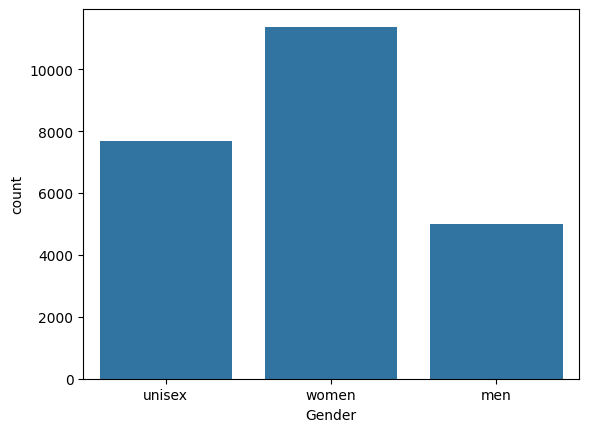

In [14]:
sns.countplot(x= data["Gender"])

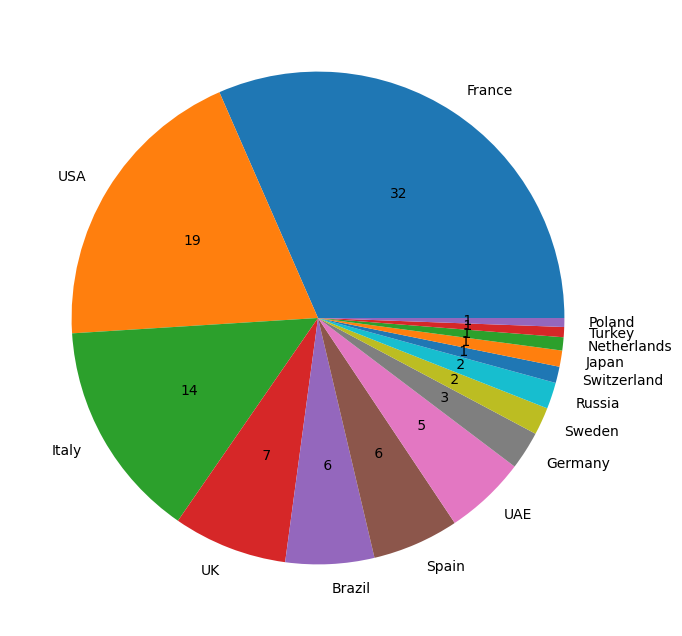

In [15]:
plt.figure(figsize=(8,8))
x= data["Country"].value_counts().head(15)
plt.pie(x, labels= x.index, autopct="%2.f")
plt.show()

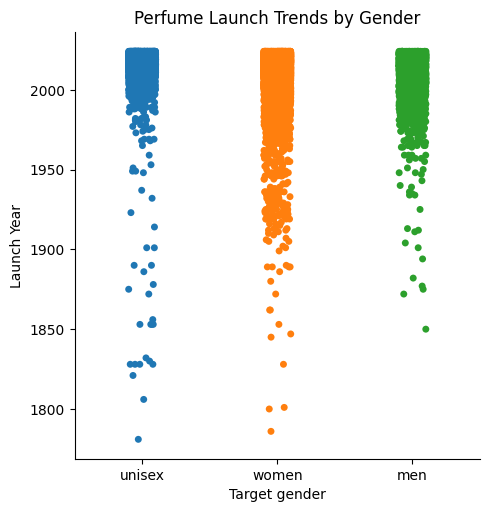

In [35]:
sns.catplot(x= data["Gender"],y=data["Year"], hue= data["Gender"] )
plt.title("Perfume Launch Trends by Gender")
plt.xlabel("Target gender")
plt.ylabel("Launch Year")
plt.show()

Text(0, 0.5, 'Total Perfumes Launched')

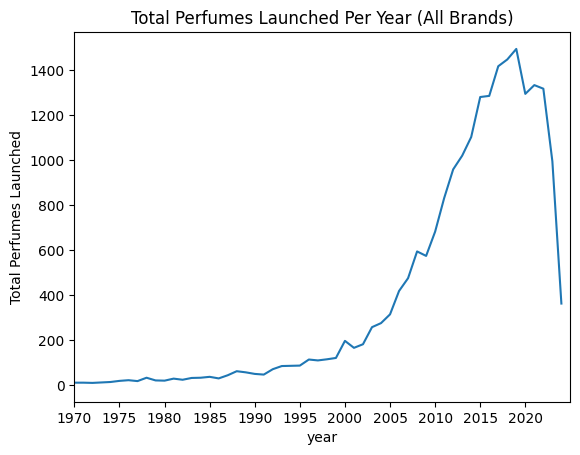

In [ ]:
x= data.groupby("Year")["Perfume"].count()
sns.lineplot(x)
plt.xlim(1970, 2025)

plt.xticks(np.arange(1970, 2025, 5))
plt.title("Total Perfumes Launched Per Year (All Brands)")
plt.xlabel("year")
plt.ylabel("Total Perfumes Launched")